### 模型控制

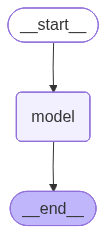

In [22]:
import os
import operator
from langchain_openai import ChatOpenAI
from langgraph.graph import START,END,StateGraph
from langchain_core.messages import AIMessage, AnyMessage
from typing_extensions import TypedDict
from typing import Any,Annotated,Literal
from langchain_core.runnables.config import RunnableConfig

class State(TypedDict):
    messages:Annotated[list, operator.add]

aliModel = ChatOpenAI(
        model="qwen3.6-plus",
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        api_key=os.getenv("DASHSCOPE_API_KEY")
        )

deepseekModel = ChatOpenAI(
        model="deepseek-v4-pro",
        base_url="https://api.deepseek.com",
        api_key=os.getenv("DEEPSEEK_API_KEY")
        )

models = {
    "aliModel" : aliModel,
    "deepseekModel" : deepseekModel
}

def call_model(state:State,config:RunnableConfig):
    modelName = config["configurable"].get("model","deepseekModel")
    model = models[modelName]
    respone = model.invoke(state["messages"])
    print(respone)
    return {"message":[respone]}

graph = StateGraph(State)

graph.add_node("model",call_model)
graph.add_edge(START,"model")
graph.add_edge("model",END)

graph_builder = graph.compile()

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [11]:
from langchain_core.messages import HumanMessage

r = graph_builder.invoke({"messages":[HumanMessage(content="你好呀！你是谁？")]})

content='你好呀！👋\n\n我是DeepSeek，由深度求索公司创造的AI助手！很高兴认识你！\n\n我目前是DeepSeek最新版本的模型，知识截止到2025年5月。简单来说，我就是一个热心肠的智能小帮手，可以帮你：\n\n✨ **处理各种文字工作** - 写作、翻译、编程、分析问题\n📄 **读取文件内容** - 支持上传图片、PDF、Word、Excel、PPT等文件，从中提取文字信息\n🔗 **阅读链接** - 虽然不能直接打开网页，但可以读取你分享的链接内容\n🌐 **联网搜索** - 需要的时候可以帮你上网查找最新信息（需要你手动开启这个功能哦）\n\n重点是——**完全免费**！无论是网页版还是App都随便用，上下文能达到1M，可以一口气处理超长文本，比如整本小说！\n\n有什么我可以帮你的吗？无论是学习、工作还是日常闲聊，我都很乐意陪你聊聊～😊' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 309, 'prompt_tokens': 9, 'total_tokens': 318, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 101, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 9}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-pro', 'system_fingerprint': 'fp_9954b31ca7_prod0820_fp8_kvcache_20260402', 'id': 'c8b2429c-44b1-4aee-b525-f3c575bb9efc', 'finish_reason

#### 动态切换模型


In [12]:
config = {"configurable":{"model":"aliModel"}}
r = graph_builder.invoke({"messages":[HumanMessage(content="你好呀！你是谁？")]},config)


content='你好呀！我是 Qwen（通义千问），由阿里巴巴集团旗下通义实验室自主研发的大语言模型。很高兴为你服务！有什么我可以帮你的吗？' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 371, 'prompt_tokens': 15, 'total_tokens': 386, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 333, 'rejected_prediction_tokens': None, 'text_tokens': 371}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': None, 'text_tokens': 15}}, 'model_provider': 'openai', 'model_name': 'qwen3.6-plus', 'system_fingerprint': None, 'id': 'chatcmpl-82bc5566-3521-9e45-9b84-7e83f82f0619', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e0b8f-3d92-7083-a371-d87086c15499-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 15, 'output_tokens': 371, 'total_tokens': 386, 'input_token_details': {}, 'output_token_details': {'reasoning': 333}}


### 应用例子

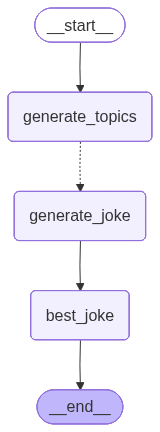

In [24]:
import os
import operator
from langgraph.types import Send
from langgraph.graph import END, StateGraph, START
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict
from typing import Any,Annotated,Literal
from IPython.display import Image, display
import json
from langchain_core.messages import HumanMessage

def _parse_model_json(content: str) -> dict:
    """从模型回复中取出 JSON 对象（兼容 markdown 代码块）。"""
    text = (content or "").strip()
    if "```" in text:
        parts = text.split("```")
        for i in range(1, len(parts), 2):
            block = parts[i].strip()
            if block.lower().startswith("json"):
                block = block[4:].lstrip("\n") if len(block) >= 4 else block
            if block.startswith("{"):
                try:
                    return json.loads(block)
                except json.JSONDecodeError:
                    continue
    start, end = text.find("{"), text.rfind("}")
    if start != -1 and end > start:
        return json.loads(text[start : end + 1])
    return json.loads(text)

class Subjects(BaseModel):
    subjects: list[str]

class Joke(BaseModel):
    joke: str

class BestJoke(BaseModel):
    id: int = Field(description="最佳笑话的索引，从 0 开始", ge=0)

aliModel = ChatOpenAI(
        model="qwen3.6-plus",
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        api_key=os.getenv("DASHSCOPE_API_KEY")
        )

# 这将是主图的整体状态。
# 它将包含一个主题(我们期望用户提供)
# 然后将生成一个主题列表，并为每个主题生成一个笑话
class OverallState(TypedDict):
    topic: str
    subjects: list[str]
    # 注意这里我们使用 operator.add
    # 这是因为我们想把从各个节点生成的所有笑话
    # 合并回一个列表 - 这本质上是"归约"部分
    jokes: Annotated[list, operator.add]
    best_selected_joke: str

# 用于生成笑话
class JokeState(TypedDict):
    subject: str

# 这是我们用来生成笑话主题的函数
def generate_topics(state: OverallState):
    topic = state["topic"]
    prompt = (
        "请以 json 格式返回。\n"
        '{"subjects": ["主题1", "主题2"]}\n'
        f"给出 2 到 5 个与以下主题相关的例子: {topic}\n"
        "只返回 json，不要其他文字。"
    )
    raw = aliModel.invoke([HumanMessage(content=prompt)]).content
    data = _parse_model_json(str(raw))
    return {"subjects": Subjects.model_validate(data).subjects}

# 这里我们根据给定的主题生成笑话
def generate_joke(state: JokeState):
    subject = state["subject"]
    prompt = (
        "请以 json 格式返回。\n"
        '{"joke": "..."}\n'
        f"请生成一个关于 {subject} 的笑话。\n"
        "只返回 json。"
    )
    raw = aliModel.invoke([HumanMessage(content=prompt)]).content
    data = _parse_model_json(str(raw))
    return {"jokes": [Joke.model_validate(data).joke]}

# 这里我们定义映射到生成的主题上的逻辑
# 我们将在图中使用这个作为边缘
def continue_to_jokes(state: OverallState):
    # 我们将返回一个 Send 对象列表
    # 每个 Send 对象包含图中节点的名称
    # 以及要发送到该节点的状态
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    topic = state["topic"]
    prompt = (
        "请以 json 格式返回。\n"
        '{"id": 0}\n'
        f"下面是关于 {topic} 的笑话列表，请选出最好的一个，id 从 0 开始:\n"
        f"{jokes}\n"
        "只返回 json。"
    )
    raw = aliModel.invoke([HumanMessage(content=prompt)]).content
    data = _parse_model_json(str(raw))
    best_id = min(max(BestJoke.model_validate(data).id, 0), len(state["jokes"]) - 1)
    return {"best_selected_joke": state["jokes"][best_id]}


# 创建一个状态图
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)

graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)
graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [25]:
for s in graph_builder.stream({"topic":"动物"}):
    print(s)

{'generate_topics': {'subjects': ['哺乳动物', '鸟类', '爬行动物', '水生动物', '昆虫']}}
{'generate_joke': {'jokes': ["为什么哺乳动物从不玩捉迷藏？因为每次被找到时，它们都会说：'这可是凭本事长出来的毛，凭什么要躲！'"]}}
{'generate_joke': {'jokes': ['为什么鸟不喜欢上网？因为它们怕遇到‘鹰’险！']}}
{'generate_joke': {'jokes': ['为什么昆虫从不玩捉迷藏？因为它们一躲起来就‘露虫’了！']}}
{'generate_joke': {'jokes': ['为什么蜥蜴从不参加扑克牌游戏？因为它们总是被看穿底牌，而且一紧张就‘蜥’里糊涂掉尾巴！']}}
{'generate_joke': {'jokes': ["为什么鱼从来不吵架？因为它们一开口就'吐'泡泡，气都跑光啦！"]}}
{'best_joke': {'best_selected_joke': '为什么蜥蜴从不参加扑克牌游戏？因为它们总是被看穿底牌，而且一紧张就‘蜥’里糊涂掉尾巴！'}}


### `with_structured_output` 在做什么（对照小实验）

同一任务：**从一句中文简介里抽出「姓名」「爱好」**。

| 方式 | `invoke` 得到什么 | 你怎么用字段 |
|------|------------------|--------------|
| **普通 `invoke`** | `AIMessage`，文本在 **`content` 字符串**里 | 自己处理 markdown 代码块、`json.loads`、容错 |
| **`with_structured_output(模型)`** | **已是 Pydantic 实例**（如 `Person`） | 直接写 **`result.name`**，也可 **`result.model_dump()`** |

下面示例单独起一个 `demo_llm`（默认 **DeepSeek**），与上方「笑话图」里用的 DashScope 解耦。代码里已对 DeepSeek 设置 **`extra_body={"thinking": {"type": "disabled"}}`（非思考模式）**，减少与 `tool_choice` / 结构化调用的冲突。说明：**DeepSeek 往往仍不支持 LangChain 默认的 `response_format`/`parsed`**，因此 `with_structured_output` 使用 **`method="function_calling"`**；若仍失败，会自动用「上一步 `invoke` 的 JSON + `model_validate`」兜底，终点仍是 `Person` 实例。

In [ ]:
import json
import os
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# 对照实验专用（避免与上方 DashScope 笑话链路的模型状态混在一起）
demo_llm = ChatOpenAI(
    model="deepseek-v4-flash",
    base_url="https://api.deepseek.com",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    temperature=0,
    # DeepSeek 官方：关闭思考模式（非推理链），利于 tool / structured 组合
    extra_body={"thinking": {"type": "disabled"}},
)

class Person(BaseModel):
    """模型输出要对齐的 schema（字段名固定，便于程序后续使用）。"""
    name: str = Field(description="人物姓名")
    hobby: str = Field(description="一项爱好")

user_text = "用户简介：姓名王五，业余爱好是徒步和摄影，住在杭州。"

# ----- 1) 普通 invoke：拿到的是「整条消息」，结构化信息在字符串里 -----
plain = demo_llm.invoke(
    [
        HumanMessage(
            content=(
                user_text
                + "\n\n请只输出一行合法 JSON，键为 name、hobby（hobby 只填一个主要爱好）。不要其它解释。"
            )
        )
    ]
)
print("=== 普通 invoke ===")
print("返回类型:", type(plain).__name__)
print("content 类型:", type(plain.content).__name__)
print("content 原文:\n", plain.content)
print()

# ----- 2) with_structured_output：LangChain 期望最终得到 Person 实例 -----
# 默认（不写 method）会走 response_format / parsed，DeepSeek 常报：
# "This response_format type is unavailable now"
# 因此显式 method="function_calling"；若仍失败，用「上一步 JSON 字符串 + model_validate」兜底，
# 便于对照：终点都是 Person，只是中间是否由框架代劳。
print("=== with_structured_output(Person) ===")
parsed = None
how = ""
try:
    structured_runnable = demo_llm.with_structured_output(
        Person, method="function_calling"
    )
    parsed = structured_runnable.invoke([HumanMessage(content=user_text)])
    how = "function_calling（工具参数对齐 schema）"
except Exception as e:
    print("with_structured_output 不可用，改用兜底:", type(e).__name__, str(e)[:100], "...")
    raw_json = plain.content.strip()
    parsed = Person.model_validate(json.loads(raw_json))
    how = "invoke 的 JSON 字符串 + json.loads + Person.model_validate（手写）"

print("本次路径:", how)
print("返回类型:", type(parsed).__name__)
print("直接点属性 — name:", parsed.name, "  hobby:", parsed.hobby)
print("转 dict 给下游:", parsed.model_dump())

=== 普通 invoke ===
返回类型: AIMessage
content 类型: str
content 原文:
 {"name":"王五","hobby":"徒步"}

=== with_structured_output(Person) ===
本次路径: function_calling（工具参数对齐 schema）
返回类型: Person
直接点属性 — name: 王五   hobby: 徒步和摄影
转 dict 给下游: {'name': '王五', 'hobby': '徒步和摄影'}


: 